# EEG Data Analysis – Brain2RL

Explores the `alpha_wave_arm_data` dataset.

**Dataset**: Manual 3D Control of an Assistive Robotic Manipulator Using Alpha Rhythms  
**Subjects**: 8 (s1–s8), 2 recording days each (d1, d2) → 16 files  
**Board**: OpenBCI Cyton WiFi (board_id=5, BrainFlow format)  
**Sample rate**: 250 Hz  
**EEG channels** (8): POz, PO3, PO4, PO7, PO8, O1, O2, Oz  

---

## Data format (23 comma-separated columns, no header)
| Col | Name | Description |
|-----|------|-------------|
| 0 | sample_index | rolling packet counter |
| 1–8 | POz PO3 PO4 PO7 PO8 O1 O2 Oz | EEG in raw ADC units (μV after ×scale) |
| 9–11 | accel_x accel_y accel_z | Analog channels 19–21 (accelerometer) |
| 12–20 | other_0 … other_8 | Board status / aux bytes |
| 22 | timestamp | Unix timestamp (seconds) |

In [1]:
import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

DATA_DIR = project_root / 'data' / 'alpha_wave_arm_data' / 'alpha-training-task'

# ── Column layout (BrainFlow Cyton WiFi, board_id=5) ──────────────────────────
EEG_NAMES   = ['POz', 'PO3', 'PO4', 'PO7', 'PO8', 'O1', 'O2', 'Oz']   # cols 1-8
ACCEL_NAMES = ['accel_x', 'accel_y', 'accel_z']                         # cols 9-11
N_OTHER     = 9                                                           # cols 12-20
OTHER_NAMES = [f'other_{i}' for i in range(N_OTHER)]
ALL_COLS    = ['sample_index'] + EEG_NAMES + ACCEL_NAMES + OTHER_NAMES + ['timestamp']
# Total: 1 + 8 + 3 + 9 + 1 = 22 … but we saw 23 values.  Add one extra just in case.
# We will let pandas detect the exact count and trim/pad to the names we care about.

FS = 250.0   # Hz
print(f'Data dir : {DATA_DIR}')
print(f'Expected columns: {len(ALL_COLS)}')
files = sorted(DATA_DIR.glob('*.txt'))
print(f'TXT files found: {len(files)}')

Data dir : /home/jdcjdb/brain2rl/data/alpha_wave_arm_data/alpha-training-task
Expected columns: 22
TXT files found: 16


/home/jdcjdb/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load raw EEG data (correct CSV parser)

In [2]:
def load_eeg_txt(path: Path) -> pd.DataFrame:
    """
    Load a BrainFlow Cyton WiFi .txt file.
    Files are COMMA-separated with NO header row.
    """
    # Read as raw comma-separated, no header
    df = pd.read_csv(path, sep=',', header=None, dtype=float, on_bad_lines='skip')
    n_cols = df.shape[1]  # actual column count in this file

    # Build column names to match actual column count
    names = ALL_COLS[:n_cols]
    if len(names) < n_cols:
        names += [f'extra_{i}' for i in range(n_cols - len(names))]
    df.columns = names
    return df


# Parse subject/day from filename
def parse_subject_day(filename: str):
    m = re.match(r'(s\d+)_?(d\d+)', Path(filename).stem)
    return (m.group(1), m.group(2)) if m else (None, None)


# Load one file to inspect
ex = load_eeg_txt(files[0])
print(f'File   : {files[0].name}')
print(f'Shape  : {ex.shape}  (rows × cols)')
print(f'Columns: {ex.columns.tolist()}')
ex.head()

File   : s1_d1_training.txt
Shape  : (125298, 23)  (rows × cols)
Columns: ['sample_index', 'POz', 'PO3', 'PO4', 'PO7', 'PO8', 'O1', 'O2', 'Oz', 'accel_x', 'accel_y', 'accel_z', 'other_0', 'other_1', 'other_2', 'other_3', 'other_4', 'other_5', 'other_6', 'other_7', 'other_8', 'timestamp', 'extra_0']


,sample_index,POz,PO3,PO4,PO7,PO8,O1,O2,Oz,accel_x,...,other_1,other_2,other_3,other_4,other_5,other_6,other_7,other_8,timestamp,extra_0
0,182.0,7066.727051,20267.533203,20846.308594,28212.236328,26441.800781,28152.958984,25936.091797,31333.970703,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.591274e+09
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012,...,0.0,96.0,255.0,240.0,31.0,32.0,0.0,0.0,0.0,1.591274e+09
2,1.0,6266.758301,19028.017578,19759.992188,26663.707031,23540.029297,24577.150391,22950.279297,26942.748047,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.591274e+09
3,2.0,6242.931641,19001.642578,19740.031250,26641.177734,23523.869141,24554.843750,22932.687500,26923.345703,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.591274e+09
4,3.0,6250.352051,18997.730469,19744.189453,26654.431641,23528.406250,24569.103516,22938.611328,26928.642578,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.591274e+09


In [3]:
# Quick sanity check – EEG values should be in ~6000–30000 range (raw ADC)
print('EEG channel stats (raw ADC units):')
ex[EEG_NAMES].describe().round(1)

EEG channel stats (raw ADC units):


,POz,PO3,PO4,PO7,PO8,O1,O2,Oz
count,125298.0,125298.0,125298.0,125298.0,125298.0,125298.0,125298.0,125298.0
mean,6223.9,22070.7,20748.9,28441.7,23177.7,24789.6,21983.7,26318.4
std,62.2,1407.5,817.4,1579.9,458.8,760.6,351.0,626.3
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,6171.9,20952.3,19948.6,26865.8,22890.7,24148.8,21698.4,25736.1
50%,6228.6,22435.4,20576.7,28227.3,23045.5,24498.4,21876.7,26206.0
75%,6273.6,23145.2,21427.7,29749.3,23486.5,25408.1,22220.3,26789.4
max,7066.7,24139.2,22464.0,31573.9,26441.8,28153.0,25936.1,31334.0


## 2. Load all subjects (s1–s8, d1–d2)

In [4]:
all_dfs = []
for f in files:
    try:
        d = load_eeg_txt(f)
        subject, day = parse_subject_day(f.name)
        d['subject']  = subject
        d['day']      = day
        d['filename'] = f.name
        all_dfs.append(d)
        print(f'  {f.name}: {d.shape}')
    except Exception as e:
        print(f'  ERROR {f.name}: {e}')

df_all = pd.concat(all_dfs, ignore_index=True)
print(f'\nTotal samples  : {len(df_all):,}')
print(f'Total duration : {len(df_all)/FS/60:.1f} min')
print(f'Subjects       : {sorted(df_all["subject"].unique())}')
print(f'Days           : {sorted(df_all["day"].unique())}')

  s1_d1_training.txt: (125298, 26)
  s1_d2_training.txt: (125256, 26)
  s2_d1_training.txt: (125208, 26)
  s2_d2_training.txt: (125196, 26)
  s3_d1_training.txt: (125076, 26)
  s3_d2_training.txt: (125508, 26)
  s4_d1_training.txt: (125520, 26)
  s4_d2_training.txt: (125466, 26)
  s5_d1_training.txt: (125478, 26)
  s5_d2_training.txt: (125220, 26)
  s6_d1_training.txt: (125298, 26)
  s6_d2_training.txt: (125520, 26)
  s7_d1_training.txt: (125466, 26)
  s7_d2_training.txt: (125484, 26)
  s8_d1_training.txt: (125220, 26)
  s8_d2_training.txt: (125238, 26)

Total samples  : 2,005,452
Total duration : 133.7 min
Subjects       : ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
Days           : ['d1', 'd2']


## 3. EEG signal visualization

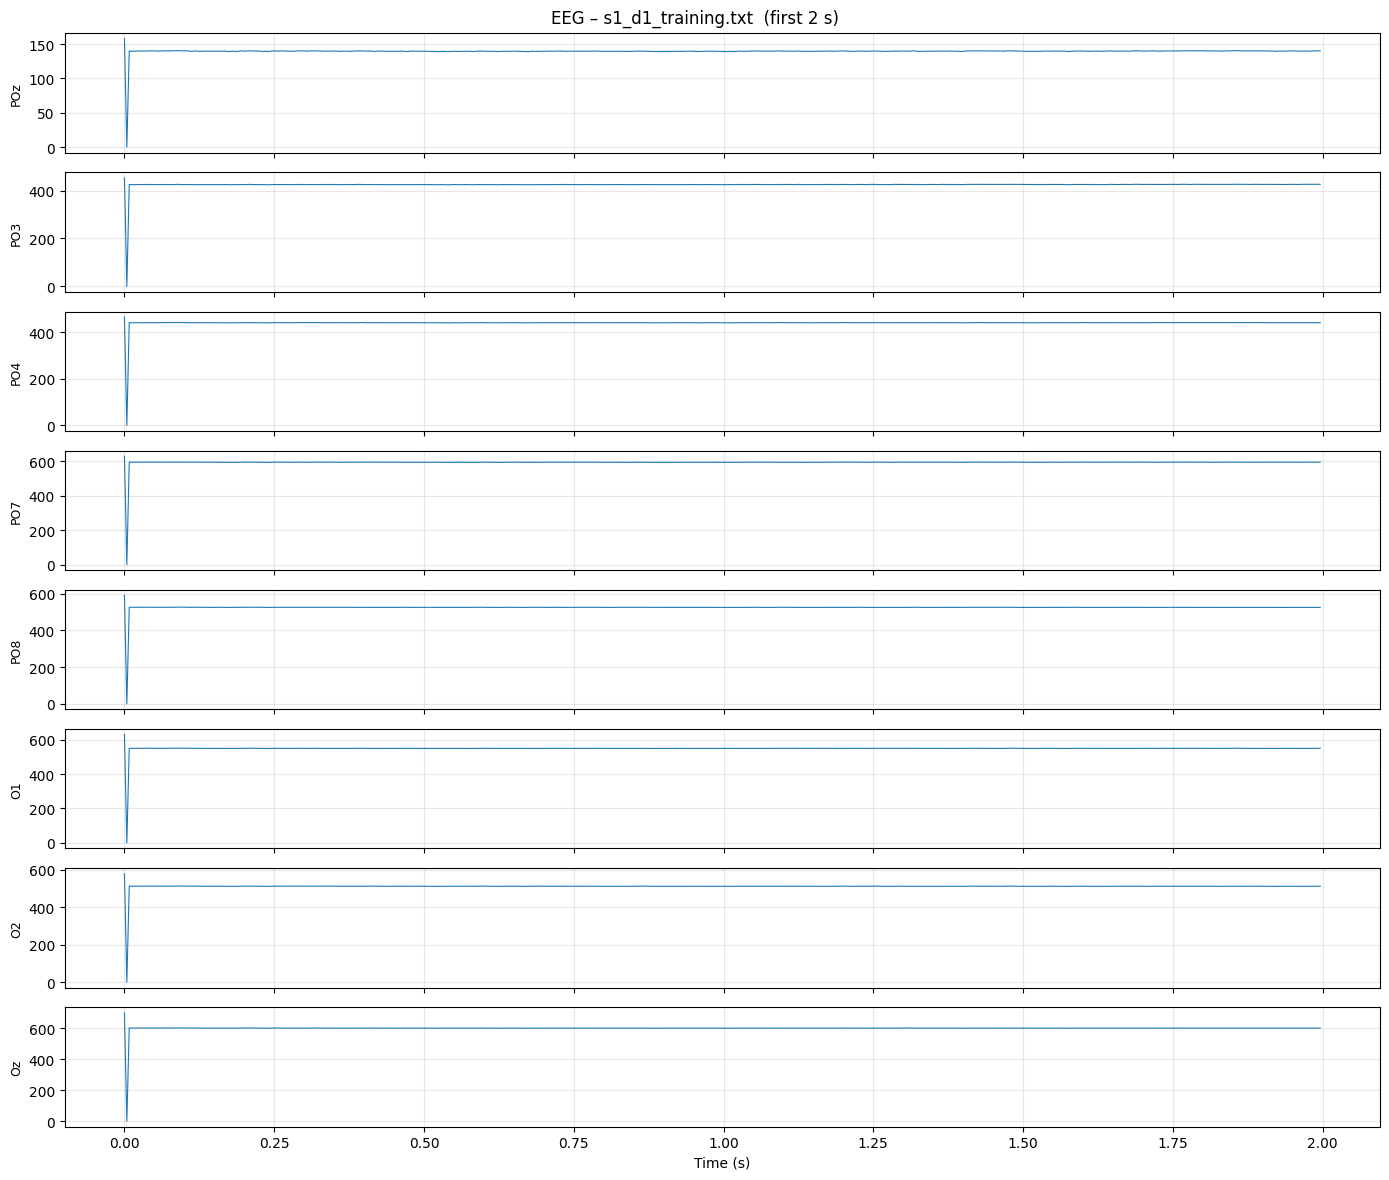

In [5]:
# Convert raw ADC → μV  (OpenBCI Cyton scale factor)
CYTON_SCALE = (4.5 / (2**23 - 1)) / 24 * 1e6   # ≈ 0.022 μV / count
df_uv = ex.copy()
df_uv[EEG_NAMES] = df_uv[EEG_NAMES] * CYTON_SCALE

N_SHOW = len(EEG_NAMES)   # 8 channels
T_SHOW = 500              # first 500 samples = 2 seconds

fig, axes = plt.subplots(N_SHOW, 1, figsize=(14, N_SHOW * 1.5), sharex=True)
subset = df_uv.iloc[:T_SHOW]
time_s = np.arange(T_SHOW) / FS

for i, ch in enumerate(EEG_NAMES):
    axes[i].plot(time_s, subset[ch].values, linewidth=0.8)
    axes[i].set_ylabel(ch, fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'EEG – {files[0].name}  (first 2 s)', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Power Spectral Density – Alpha band highlight

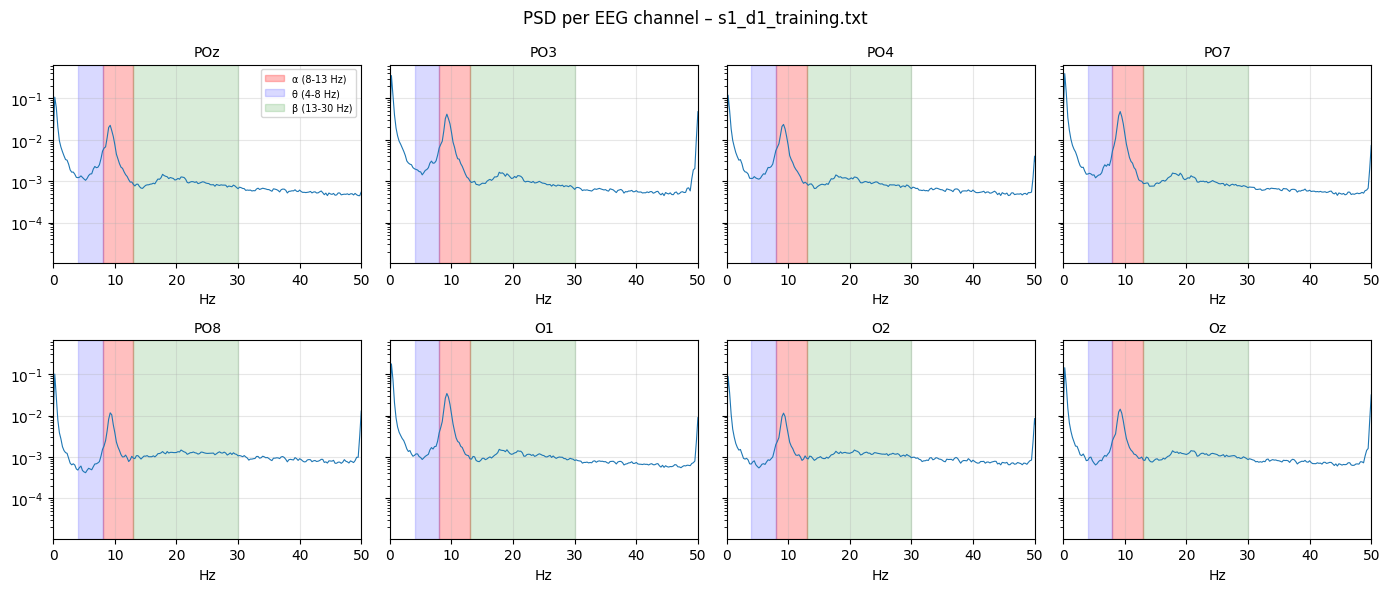

In [6]:
from scipy import signal as sp_signal

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=True)
axes = axes.flatten()

sig_all = df_uv[EEG_NAMES].values  # (N, 8)
for i, ch in enumerate(EEG_NAMES):
    freqs, psd = sp_signal.welch(sig_all[:, i], fs=FS, nperseg=int(FS * 4))
    axes[i].semilogy(freqs, psd, linewidth=0.8)
    axes[i].axvspan(8, 13, alpha=0.25, color='red',   label='α (8-13 Hz)')
    axes[i].axvspan(4,  8, alpha=0.15, color='blue',  label='θ (4-8 Hz)')
    axes[i].axvspan(13, 30, alpha=0.15, color='green', label='β (13-30 Hz)')
    axes[i].set_title(ch, fontsize=10)
    axes[i].set_xlim(0, 50)
    axes[i].set_xlabel('Hz')
    if i == 0:
        axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f'PSD per EEG channel – {files[0].name}', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Band-pass filter (alpha: 8–13 Hz) and envelope

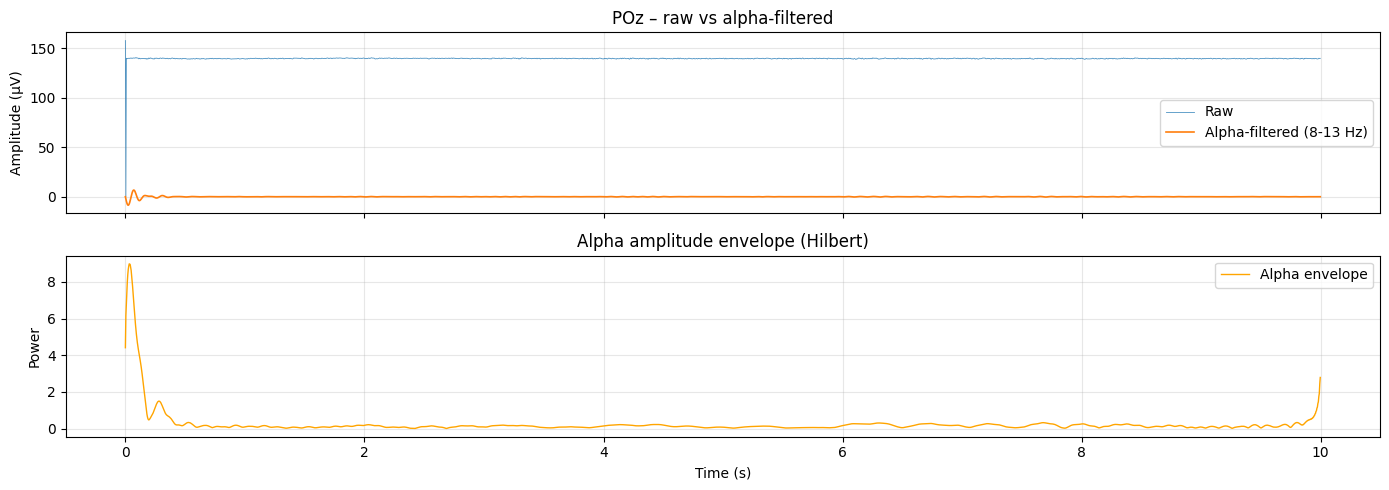

In [7]:
def bandpass(data: np.ndarray, lo: float, hi: float, fs: float, order: int = 4) -> np.ndarray:
    """data: (T,) or (C, T)"""
    nyq = fs / 2.0
    b, a = sp_signal.butter(order, [lo / nyq, hi / nyq], btype='band')
    return sp_signal.filtfilt(b, a, data, axis=-1)

T_VIZ = int(FS * 10)   # 10 seconds
ch_idx = 0             # POz

raw_sig  = df_uv[EEG_NAMES[ch_idx]].values[:T_VIZ]
alpha_sig = bandpass(raw_sig, 8, 13, FS)
time_s    = np.arange(T_VIZ) / FS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(time_s, raw_sig,   linewidth=0.6, label='Raw', alpha=0.8)
ax1.plot(time_s, alpha_sig, linewidth=1.2, label='Alpha-filtered (8-13 Hz)')
ax1.set_ylabel('Amplitude (μV)')
ax1.set_title(f'{EEG_NAMES[ch_idx]} – raw vs alpha-filtered')
ax1.legend(); ax1.grid(True, alpha=0.3)

envelope = np.abs(sp_signal.hilbert(alpha_sig))
ax2.plot(time_s, envelope, color='orange', linewidth=1.0, label='Alpha envelope')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Power')
ax2.set_title('Alpha amplitude envelope (Hilbert)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Cross-subject alpha power comparison

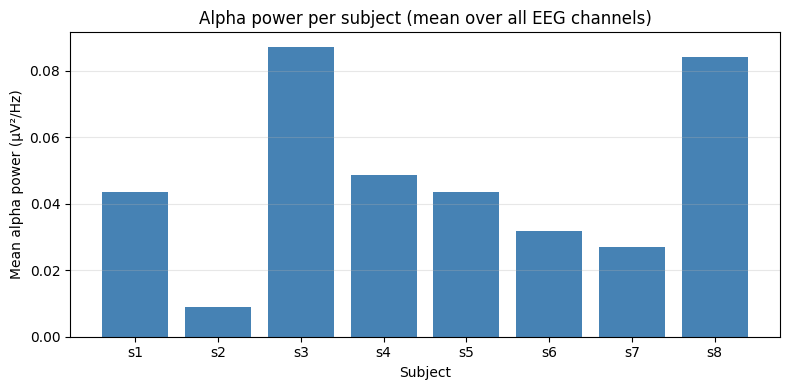

In [8]:
subj_alpha = {}   # subject → mean alpha power per channel

for subj in sorted(df_all['subject'].unique()):
    chunk = df_all[df_all['subject'] == subj][EEG_NAMES].values.astype(float) * CYTON_SCALE
    if len(chunk) < int(FS * 4):
        continue
    ch_pows = []
    for ci in range(len(EEG_NAMES)):
        f, p = sp_signal.welch(chunk[:, ci], fs=FS, nperseg=int(FS * 4))
        ch_pows.append(np.mean(p[(f >= 8) & (f <= 13)]))
    subj_alpha[subj] = np.mean(ch_pows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(subj_alpha.keys()), list(subj_alpha.values()), color='steelblue')
ax.set_xlabel('Subject'); ax.set_ylabel('Mean alpha power (μV²/Hz)')
ax.set_title('Alpha power per subject (mean over all EEG channels)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Samples per subject and day

subject day  n_samples  duration_min
     s1  d1     125298        8.3532
     s1  d2     125256        8.3504
     s2  d1     125208        8.3472
     s2  d2     125196        8.3464
     s3  d1     125076        8.3384
     s3  d2     125508        8.3672
     s4  d1     125520        8.3680
     s4  d2     125466        8.3644
     s5  d1     125478        8.3652
     s5  d2     125220        8.3480
     s6  d1     125298        8.3532
     s6  d2     125520        8.3680
     s7  d1     125466        8.3644
     s7  d2     125484        8.3656
     s8  d1     125220        8.3480
     s8  d2     125238        8.3492


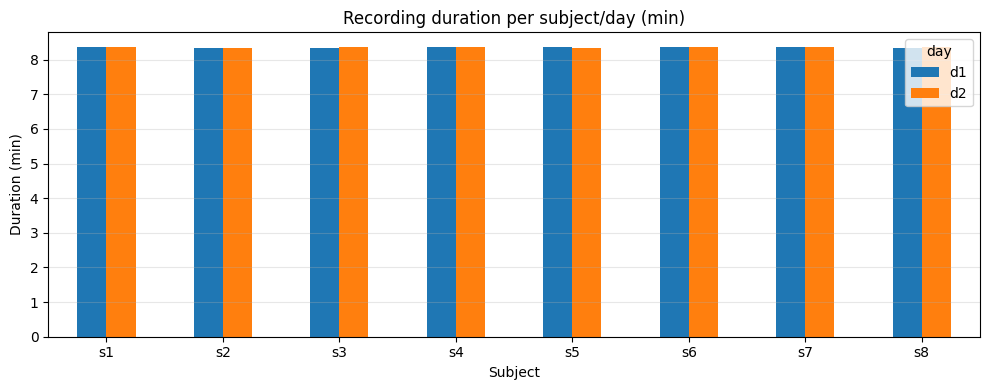

In [9]:
counts = df_all.groupby(['subject', 'day']).size().reset_index(name='n_samples')
counts['duration_min'] = counts['n_samples'] / FS / 60
print(counts.to_string(index=False))

pivot = counts.pivot(index='subject', columns='day', values='duration_min')
pivot.plot(kind='bar', figsize=(10, 4), title='Recording duration per subject/day (min)')
plt.ylabel('Duration (min)'); plt.xlabel('Subject')
plt.xticks(rotation=0); plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Other channel inspection (markers / triggers)

Task labels might be encoded in the `other_*` or `accel_*` columns as trigger markers.

In [10]:
other_present = [c for c in OTHER_NAMES if c in ex.columns]
print('Other channel unique-value counts:')
for c in ACCEL_NAMES + other_present:
    uvals = ex[c].dropna().unique()
    print(f'  {c:12s}: {len(uvals):5d} unique  min={uvals.min():.3f}  max={uvals.max():.3f}')

Other channel unique-value counts:
  accel_x     :    13 unique  min=0.000  max=0.024
  accel_y     :    12 unique  min=-0.016  max=0.006
  accel_z     :    17 unique  min=0.000  max=1.014
  other_0     :     1 unique  min=192.000  max=192.000
  other_1     :     1 unique  min=0.000  max=0.000
  other_2     :    13 unique  min=0.000  max=192.000
  other_3     :     2 unique  min=0.000  max=255.000
  other_4     :    12 unique  min=0.000  max=240.000
  other_5     :     3 unique  min=0.000  max=31.000
  other_6     :    16 unique  min=0.000  max=240.000
  other_7     :     1 unique  min=0.000  max=0.000
  other_8     :     1 unique  min=0.000  max=0.000


In [11]:
# Check if any other_* column looks like a categorical label (few distinct values)
candidate_label_cols = []
for c in other_present:
    uvals = ex[c].dropna().unique()
    if 2 <= len(uvals) <= 10:
        candidate_label_cols.append((c, sorted(uvals)))
        print(f'CANDIDATE label col: {c}  values={sorted(uvals)}')

if not candidate_label_cols:
    print('No obvious label column found in other_* channels.')
    print('The task labels likely require a separate timing/events file or are encoded across multiple cols.')

CANDIDATE label col: other_3  values=[0.0, 255.0]
CANDIDATE label col: other_5  values=[0.0, 30.0, 31.0]


## 9. Sliding window segmentation

In [12]:
def segment_signal(X: np.ndarray, window: int, stride: int) -> np.ndarray:
    """
    X      : (N_samples, N_channels)
    Returns: (N_windows, N_channels, window)  – CNN-ready format (B, C, T)
    """
    starts = range(0, len(X) - window + 1, stride)
    segs = np.stack([X[s:s+window].T for s in starts])   # (W, C, T)
    return segs


WINDOW_SAMPLES = int(FS * 1.0)  # 1-second window = 250 samples
STRIDE_SAMPLES = int(FS * 0.5)  # 50% overlap = 125 samples

X_eeg = (ex[EEG_NAMES].values * CYTON_SCALE).astype(np.float32)  # (N, 8) in μV
X_win = segment_signal(X_eeg, WINDOW_SAMPLES, STRIDE_SAMPLES)    # (W, 8, 250)

print(f'Window  : {WINDOW_SAMPLES} samples = {WINDOW_SAMPLES/FS:.2f} s')
print(f'Stride  : {STRIDE_SAMPLES} samples')
print(f'Windows : {len(X_win)}')
print(f'Shape (B, C, T): {X_win.shape}')

Window  : 250 samples = 1.00 s
Stride  : 125 samples
Windows : 1001
Shape (B, C, T): (1001, 8, 250)


## 10. Channel correlation matrix

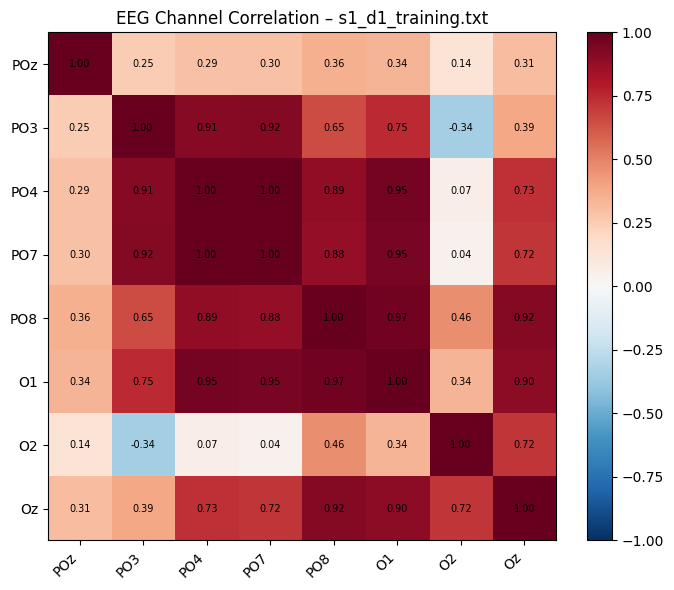

In [13]:
corr = ex[EEG_NAMES].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(8)); ax.set_yticks(range(8))
ax.set_xticklabels(EEG_NAMES, rotation=45, ha='right')
ax.set_yticklabels(EEG_NAMES)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title(f'EEG Channel Correlation – {files[0].name}')

# Annotate with values
for i in range(8):
    for j in range(8):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

## 11. Quick CNN tokenizer test (forward pass check)

In [14]:
import torch
from models.classification.action_classifier import ActionClassifier

N_CHANNELS = len(EEG_NAMES)   # 8
N_TIMES    = WINDOW_SAMPLES   # 250 (1 second at 250 Hz)
BATCH      = 4

model = ActionClassifier(
    n_channels=N_CHANNELS, n_times=N_TIMES,
    n_behavior_classes=4, n_gesture_classes=4,
    task='behavior'
)
model.eval()

# Use real windows from the data
x_real = torch.from_numpy(X_win[:BATCH]).float()   # (4, 8, 250)

with torch.no_grad():
    out = model(x_real, return_tokens=True, pool_tokens_to=16)

print('Input shape      :', x_real.shape)
print('Token shape      :', out['tokens'].shape)          # (B, 16, 128)
print('Behavior logits  :', out['behavior_logits'].shape) # (B, 4)
print(f'Token mean={out["tokens"].mean():.4f}  std={out["tokens"].std():.4f}')
print()
print('CNN tokenizer forward pass: OK')

/home/jdcjdb/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

## 12. Time-frequency analysis (spectrogram)

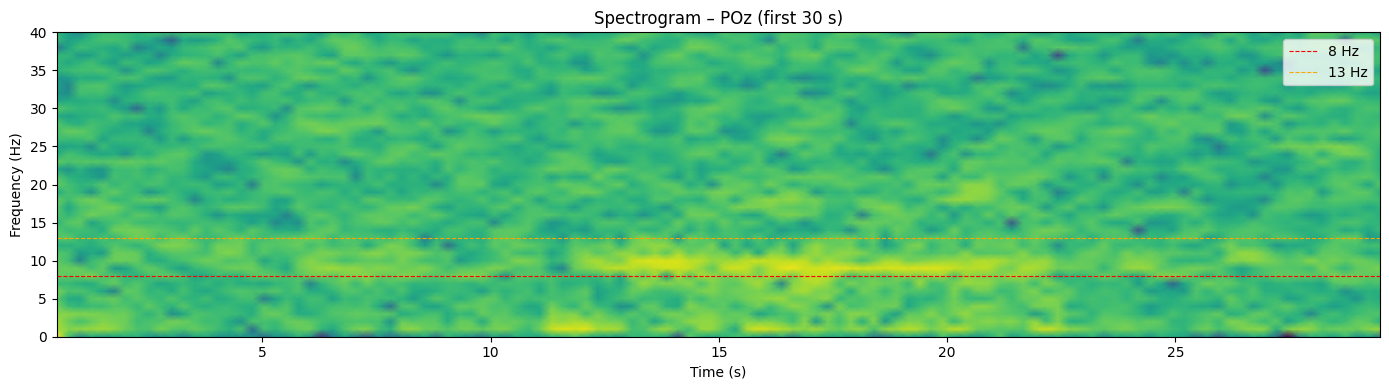

In [15]:
T_SPEC = int(FS * 30)   # 30 seconds
ch_sig = df_uv[EEG_NAMES[0]].values[:T_SPEC]   # POz

f_spec, t_spec, Sxx = sp_signal.spectrogram(
    ch_sig, fs=FS, nperseg=int(FS), noverlap=int(FS * 0.75))

fig, ax = plt.subplots(figsize=(14, 4))
ax.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')
ax.axhline(8,  color='red',   linestyle='--', linewidth=0.8, label='8 Hz')
ax.axhline(13, color='orange', linestyle='--', linewidth=0.8, label='13 Hz')
ax.set_ylim(0, 40)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title(f'Spectrogram – {EEG_NAMES[0]} (first 30 s)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 13. Accelerometer channels

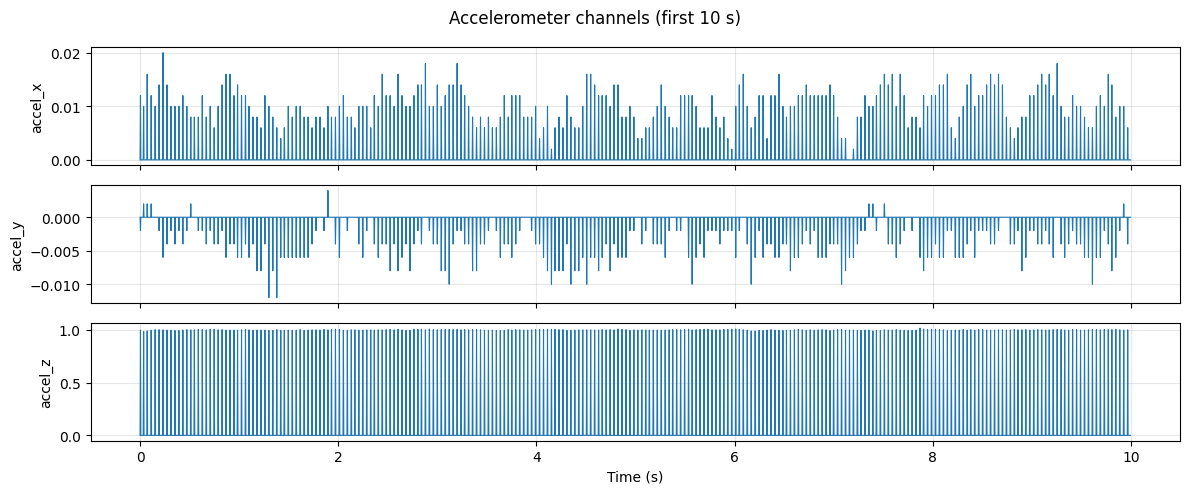

In [16]:
T_ACC = int(FS * 10)
time_s = np.arange(T_ACC) / FS

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
for i, ch in enumerate(ACCEL_NAMES):
    if ch in ex.columns:
        axes[i].plot(time_s, ex[ch].values[:T_ACC], linewidth=0.8)
        axes[i].set_ylabel(ch); axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Accelerometer channels (first 10 s)', fontsize=12)
plt.tight_layout()
plt.show()

## 14. Summary

In [17]:
print('=' * 50)
print('Dataset Summary')
print('=' * 50)
print(f'Files             : {len(files)} ({len(files)//2} subjects × 2 days)')
print(f'Total samples     : {len(df_all):,}')
print(f'Total duration    : {len(df_all)/FS/60:.1f} min')
print(f'Sampling rate     : {FS} Hz')
print(f'EEG channels      : {EEG_NAMES}')
print(f'Analog channels   : {ACCEL_NAMES}')
print(f'Window (1s, 50%)  : {X_win.shape}  (N_windows, C, T)')
print()
print('Per-subject sample count:')
print(df_all.groupby('subject').size().rename('n_samples').to_string())
print()
print('Column layout:')
print(f'  0         : sample_index')
print(f'  1–8       : EEG  {EEG_NAMES}')
print(f'  9–11      : Accel {ACCEL_NAMES}')
print(f'  12–20     : Board status / aux bytes')
print(f'  21 (last) : Unix timestamp')

Dataset Summary
Files             : 16 (8 subjects × 2 days)
Total samples     : 2,005,452
Total duration    : 133.7 min
Sampling rate     : 250.0 Hz
EEG channels      : ['POz', 'PO3', 'PO4', 'PO7', 'PO8', 'O1', 'O2', 'Oz']
Analog channels   : ['accel_x', 'accel_y', 'accel_z']
Window (1s, 50%)  : (1001, 8, 250)  (N_windows, C, T)

Per-subject sample count:
subject
s1    250554
s2    250404
s3    250584
s4    250986
s5    250698
s6    250818
s7    250950
s8    250458

Column layout:
  0         : sample_index
  1–8       : EEG  ['POz', 'PO3', 'PO4', 'PO7', 'PO8', 'O1', 'O2', 'Oz']
  9–11      : Accel ['accel_x', 'accel_y', 'accel_z']
  12–20     : Board status / aux bytes
  21 (last) : Unix timestamp
